# ===================================================================
# OPERATION HEATHSHIELD
# OWID COVID-19 Analysis for Nigeria Ministry of Health
# ===================================================================

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

print("Starting Operation HealthShield - COVID-19 Analysis for Nigeria Ministry of Health")
print("="*90)
print("\n")

Starting Operation HealthShield - COVID-19 Analysis for Nigeria Ministry of Health




In [2]:
# Load data
df_raw = pd.read_csv("../data/covid19_compact.csv")

start_date = "2020-08-29"
end_date = "2020-10-29"

df_raw = df_raw[
    (df_raw["date"] >= start_date) &
    (df_raw["date"] <= end_date)
]

df = df_raw[df_raw["code"] == "USA"]

# View summary statistics for numerical columns
numeric_columns = df.columns.tolist()

# Remove non-numerical columns
numeric_columns.remove("country")
numeric_columns.remove("date")

# View summary
print(df[numeric_columns].describe())

        total_cases     new_cases  new_cases_smoothed  \
count  6.200000e+01     62.000000           62.000000   
mean   1.462496e+06   8573.145161         8491.366369   
std    1.513746e+05   1747.411630         1068.699248   
min    1.217086e+06   4874.000000         7392.000000   
25%    1.337580e+06   7448.500000         7716.928475   
50%    1.452496e+06   8363.500000         7955.000000   
75%    1.583745e+06   9371.750000         9389.178750   
max    1.740823e+06  14272.000000        10896.429000   

       total_cases_per_million  new_cases_per_million  \
count                62.000000              62.000000   
mean               1032.894243               6.054823   
std                 106.909019               1.234117   
min                 859.572500               3.442285   
25%                 944.672153               5.260537   
50%                1025.832250               5.906760   
75%                1118.526950               6.618841   
max                1229.464200

In [3]:
## Data cleaning and transformation

# Convert the date value to a proper datetime object
df["date"] = pd.to_datetime(df["date"])
df["total_cases"] = pd.to_numeric(df["total_cases"])
df["new_cases"] = pd.to_numeric(df["new_cases"])
# df["people_vaccinated_per_hundred"] = pd.to_numeric(df["people_vaccinated_per_hundred"])
# df["people_fully_vaccinated_per_hundred"] = pd.to_numeric(df["people_fully_vaccinated_per_hundred"])

# Sort the values in the DataFrame using the date column
df = df.sort_values("date").reset_index(drop=True)

print(f"Data loaded: {len(df):,} rows from {df["date"].min().date()} to {df["date"].max().date()}")
print("\n" + "="*50 + "\n")

# Basic cleaning
# for col in numeric_columns:
#     df[col] = df[col].fillna(0)
#
# cum_fill = [
#     "total_cases", "total_deaths", "people_vaccinated_per_hundred",
#     "people_fully_vaccinated_per_hundred", "total_boosters_per_hundred"
# ]
#
# for col in cum_fill:
#     df[col] = df[col].ffill().fillna(0)

Data loaded: 62 rows from 2020-08-29 to 2020-10-29




In [4]:
# Dataset Exploration

df["cases_7d_avg"] = df["new_cases"].rolling(7, min_periods=1).mean()
df["cases_14d_avg"] = df["new_cases"].rolling(14, min_periods=1).mean()

# Rolling average - calculates the average of the last N days at each point

df["cases_7d_ago"] = df["total_cases"].shift(7)

# Date      total_cases cases_7d_ago
# Jan 1     1000        NaN
# Jan 2     1200        NaN
# Jan 3     1500        NaN
...
# Jan 8     2000        1000 -> value from Jan 1
# Jan 9     2200        1200 -> value from Jan 2
# Jan 10    2500        1500 -> value from Jan 3

# print(df[["country", "date", "total_cases", "cases_7d_ago"]].head(25))

# Doubling time (days) - how many days for total cases to double?
# Formula: doubling_time = 7 * log(2) / log(total_cases_for_the_day / cases_7d_ago)
with np.errstate(divide="ignore", invalid="ignore"):
    df["doubling_time"] = np.where(
        (df["cases_7d_ago"] > 0) & (df["total_cases"] > df["cases_7d_ago"]),
        7 * np.log(2) / np.log(df["total_cases"] / df["cases_7d_ago"]),
        np.nan
    )
# np.where(boolean expression, value_if_true, value_if_false)

# Cap at a sensible ceiling - very large values (slow spread) aren't meaningful
df["doubling_time"] = df["doubling_time"].clip(upper=365)

# Vaccination coverage gap (% of people who got 1st dosage, but not the 2nd)
df["dose1_only_pct"] = (
    df["people_vaccinated_per_hundred"] - df["people_fully_vaccinated_per_hundred"]
).clip(lower=40)

# Resilience Quadrant
case_threshold = df["new_cases_smoothed"].quantile(0.60) # top 40% = high cases
vaccination_threshold = 10 # % of fully vaccinated

def assign_quadrant(row):
    high_cases = (row.get("new_cases_smoothed", 0) or 0) > case_threshold
    high_vacc = (row.get("people_fully_vaccinated_per_hundred", 0) or 0) > vaccination_threshold

    if not high_cases and high_vacc:
        return "Q1: Stable"
    elif not high_cases and not high_vacc:
        return "Q2: Fragile"
    elif high_cases and high_vacc:
        return "Q3: Recovering"
    else:
        return "Q4: High Risk"

df["resilience_quadrant"] = df.apply(assign_quadrant, axis=1)

# print(df["resilience_quadrant"].value_counts().to_string())

# print(df[["country", "date", "total_cases", "new_cases", "people_vaccinated_per_hundred", "people_fully_vaccinated_per_hundred", "dose1_only_pct"]][50:938])

# ==========================================================================
# Objective 1: What’s happening right now, and how fast is it moving?
# ==========================================================================


OBJECTIVE 1: WHAT'S HAPPENING RIGHT NOW?


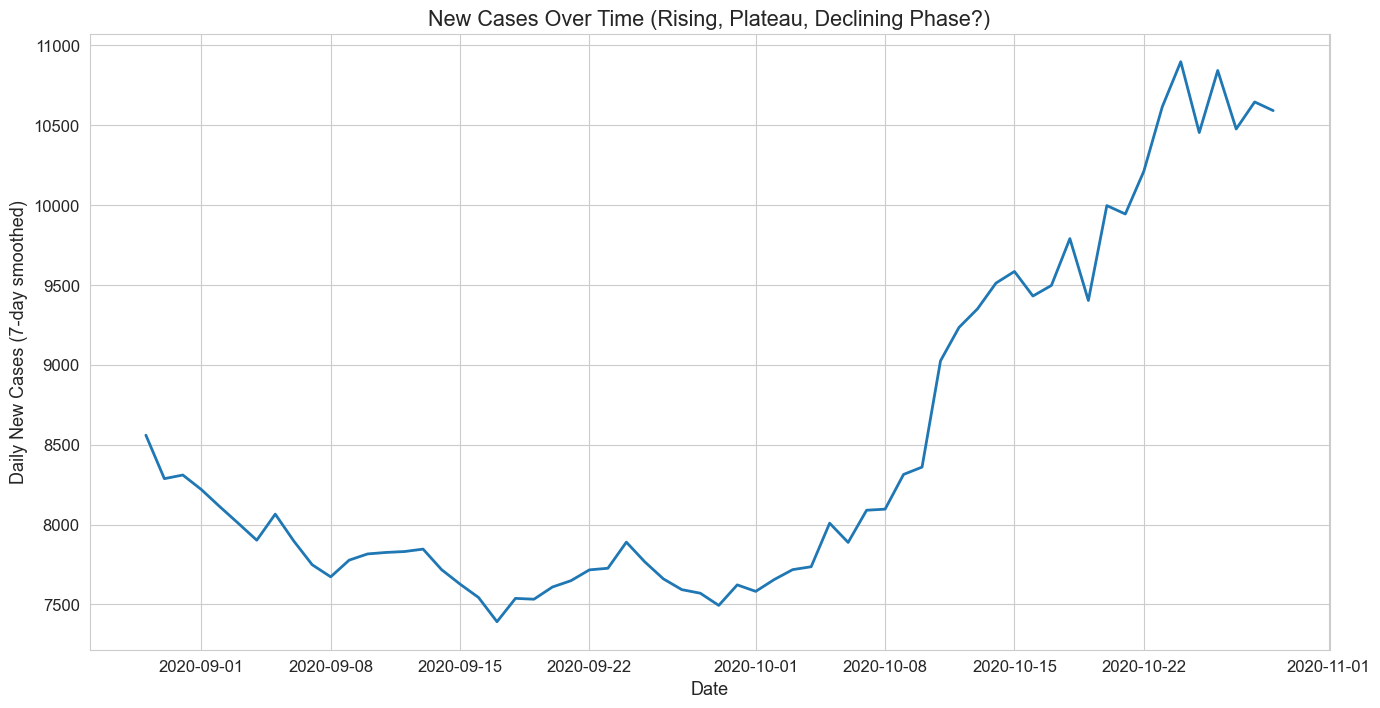

In [5]:
print("\n" + "="*70)
print("OBJECTIVE 1: WHAT'S HAPPENING RIGHT NOW?")
print("="*70)

# Epidemic Curve Analysis
plt.figure(figsize=(16, 8))
sns.lineplot(data=df, x="date", y="new_cases_smoothed", linewidth=2)
plt.title("New Cases Over Time (Rising, Plateau, Declining Phase?)")
plt.ylabel("Daily New Cases (7-day smoothed)")
plt.xlabel("Date")
plt.show()

Explain the visualization above

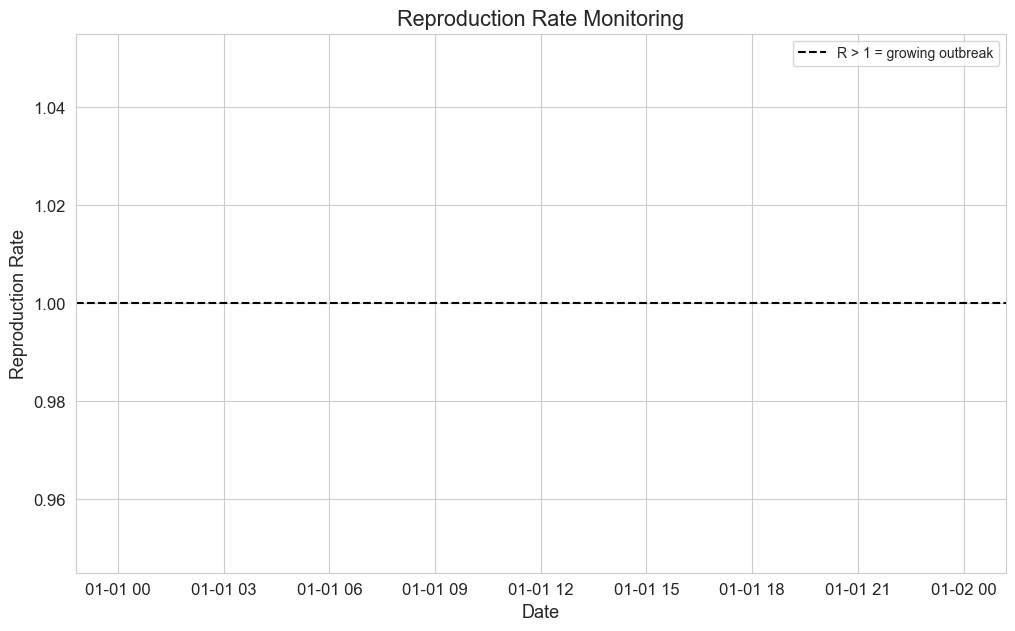

In [6]:
# Covid19 "Reproduction Rate" Monitoring

plt.figure()
sns.lineplot(data=df, x="date", y="reproduction_rate", linewidth=2)
plt.axhline(1.0, color="black", linestyle="--", label="R > 1 = growing outbreak")
plt.title("Reproduction Rate Monitoring")
plt.ylabel("Reproduction Rate")
plt.xlabel("Date")
plt.legend()
plt.show()

Explain the visualization above

ValueError: Axis limits cannot be NaN or Inf

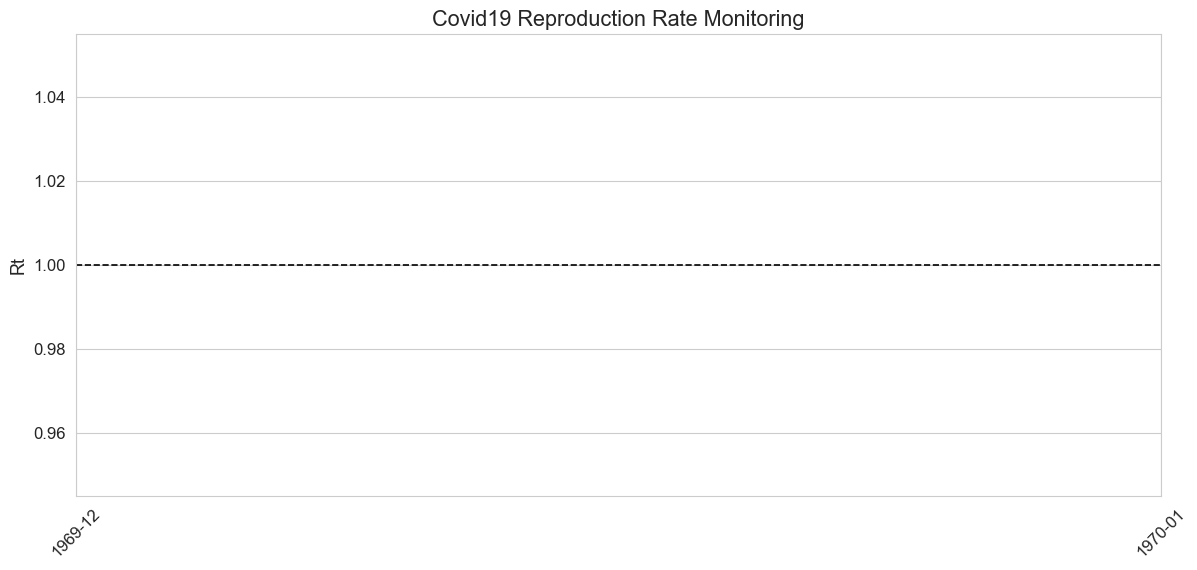

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

rep_rate_data = df.dropna(subset=["reproduction_rate", "date"])

ax.axhline(y=1.0, color="black", linestyle="--", label="Rt = 1 (threshold)", linewidth=1.2)

ax.fill_between(rep_rate_data["date"], 1, rep_rate_data["reproduction_rate"], where=(rep_rate_data["reproduction_rate"] >= 1), color="red", alpha=0.3, label="Rt > 1 (growing)")

ax.fill_between(rep_rate_data["date"], 1, rep_rate_data["reproduction_rate"], where=(rep_rate_data["reproduction_rate"] < 1), color="green", alpha=0.3, label="Rt < 1 (shrinking)")

ax.plot(rep_rate_data["date"], rep_rate_data["reproduction_rate"], linewidth=1.5)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

plt.xticks(rotation=45)
ax.set_title("Covid19 Reproduction Rate Monitoring")
ax.set_ylabel("Rt")
ax.set_ylim(0, rep_rate_data["reproduction_rate"].quantile(0.99) + 0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Explain the visualization above and how it contributes to answering the question in the 1st objective

In [ ]:
beds_per_thousand = df["hospital_beds_per_thousand"].dropna().iloc[0]
beds_per_million = beds_per_thousand * 1000
covid_capacity = beds_per_million * 0.20 # Assuming 20% of beds are allocated to Covid patients

hosp_avail = df["hosp_patients_per_million"].notna().sum()
icu_avail = df["icu_patients_per_million"].notna().sum()

if hosp_avail > 10:
    fig, ax = plt.subplots(figsize=(14, 6))
    hosp_data = df.dropna(subset=["hosp_patients_per_million"])

    ax.plot(df["date"], df["hosp_patients_per_million"])
    # ax.axhline(y=covid_capacity, color="red", linestyle="--", label="Est. Surge Capacity")
    ax.set_title("Hospital Capacity Pressure")
    ax.set_ylabel("Patients per million")
    ax.set_xlabel("Date")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    # ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# ==========================================================================
# Objective 2: Will the health system hold, or will it collapse?
# ==========================================================================

In [ ]:
# Hospital Capacity Pressure Index

WA_BPT = 0.6

beds_per_thousand = df["hospital_beds_per_thousand"].dropna().iloc[0] if not df["hospital_beds_per_thousand"].dropna().empty else WA_BPT
population = df["population"].dropna().iloc[0]

total_beds = beds_per_thousand * (population / 1000)

df["total_beds"] = total_beds
df["hosp_patients_est"] = df["hosp_patients_per_million"] * (population / 1_000_000)
df["bed_occupancy_%"] = ((df["hosp_patients_est"] / total_beds) * 100).fillna(0)

# print(df[["country", "date", "total_beds", "hosp_patients_est", "bed_occupancy_%"]].head(30))

plt.figure()
sns.lineplot(data=df, x="date", y="bed_occupancy_%", linewidth=3)
# plt.axhline(60, color="red", linestyle="--", label="Critical threshold (80%)")
plt.title(f"Hospital Capacity Pressure Index\nNigeria has only ~{int(total_beds):,} beds in total")
plt.ylabel("Est. Bed occupancy %")
plt.savefig("Hospital Capacity Pressure Index.png", dpi=300)
plt.show()

Explain the visualization above

In [91]:
# # ICU Surge Forecasting
#
# recent_df = df.copy().tail(90)
# recent_df["days"] = (recent_df["date"] - recent_df["date"].min()).dt.days
#
# if recent_df["weekly_icu_admissions_per_million"].max() > 0:
#     slope, intercept = np.polyfit(recent_df["days"], recent_df["weekly_icu_admissions_per_million"], 1)
#     # polyfit() method helps you find the best polynomial curve that fits through your data points
#     # linear trend
#     future_days = np.arange(recent_df["days"].max() + 1, recent_df["days"].max() + 29)
#     forecast = slope * future_days + intercept
#
#     plt.figure(figsize=(14, 6))
#     plt.plot(recent_df["date"], recent_df["weekly_icu_admissions_per_million"], label="Historical", linewidth=3)
#     plt.plot(recent_df["date"].max() + pd.to_timedelta(future_days, "D"), forecast, color="red", label="2-4 Week Forecast", linewidth=3)
#     plt.title("ICU Surge Forecasting (2-4 weeks ahead")
#     plt.ylabel("Weekly ICU addmissions per million")
#     plt.legend()
#     plt.show()
# else:
#     print("Incomplete data")

Explain the visualization above

# ==============================================================================
# Objective 3: Who needs the vaccine most urgently, and are we reaching them?
# ==============================================================================

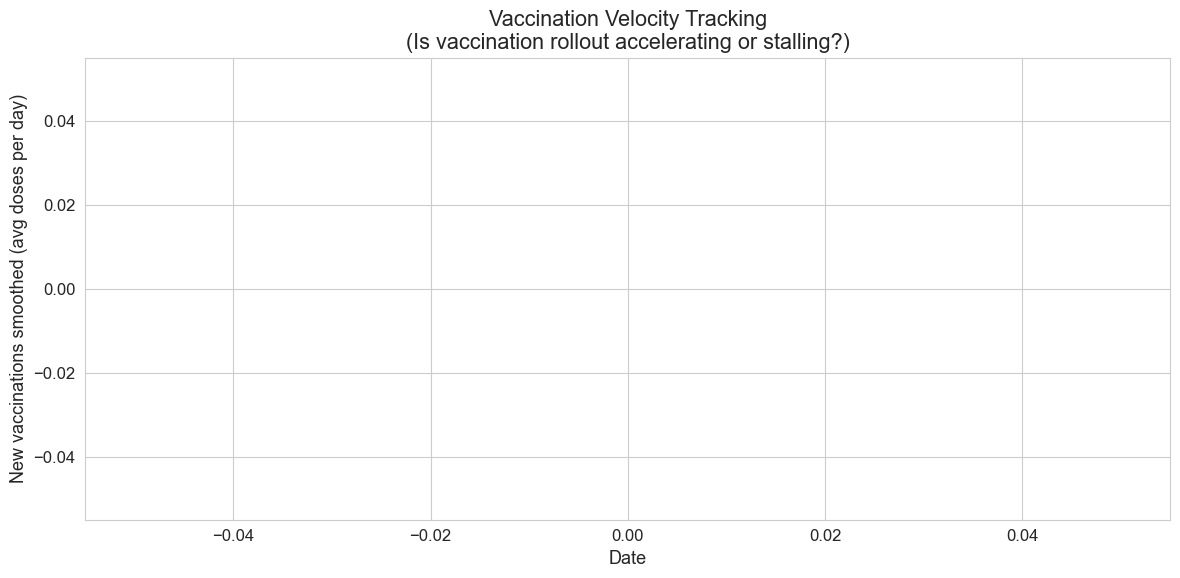

In [10]:
# Vaccination Velocity Tracking
vvt_df = df.dropna(subset=["new_vaccinations_smoothed"])

plt.figure(figsize=(14, 6))
sns.lineplot(data=vvt_df, x="date", y="new_vaccinations_smoothed", linewidth=3)
plt.title("Vaccination Velocity Tracking\n(Is vaccination rollout accelerating or stalling?)")
plt.xlabel("Date")
plt.ylabel("New vaccinations smoothed (avg doses per day)")
plt.show()

Empty DataFrame
Columns: [people_vaccinated_per_hundred]
Index: []


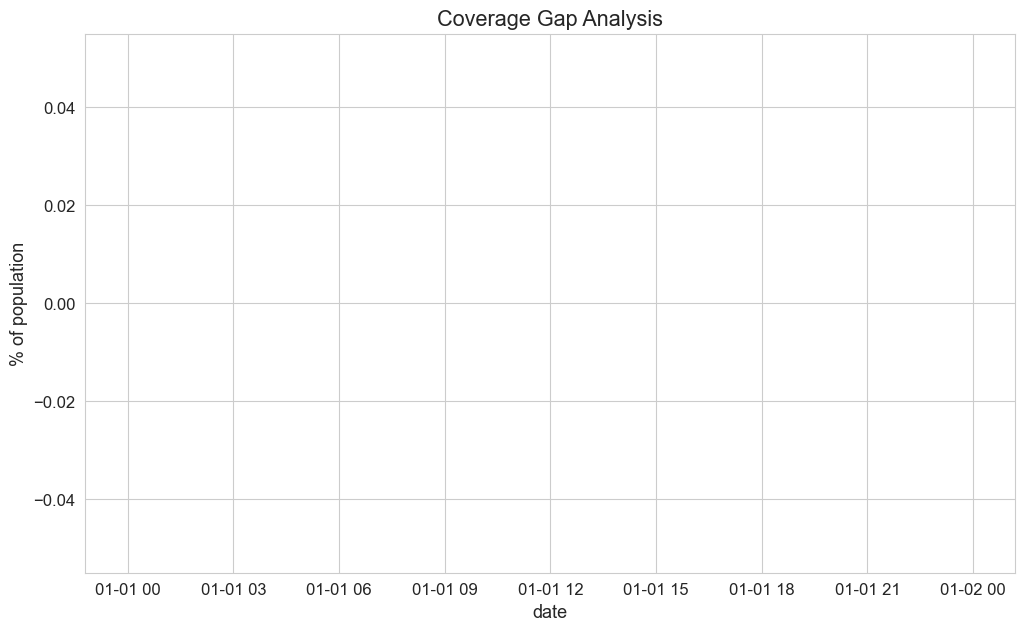

In [11]:
# Vaccination Coverage Gap Analysis - how many persons never returned for 2nd dose
vcga_df = df.dropna(subset=["people_vaccinated_per_hundred", "people_fully_vaccinated_per_hundred"])

print(vcga_df[["people_vaccinated_per_hundred"]])

plt.figure()
sns.lineplot(data=vcga_df, x="date", y="people_vaccinated_per_hundred", linewidth=3)
sns.lineplot(data=vcga_df, x="date", y="people_fully_vaccinated_per_hundred", linewidth=3)
plt.title("Coverage Gap Analysis")
plt.ylabel("% of population")
plt.show()